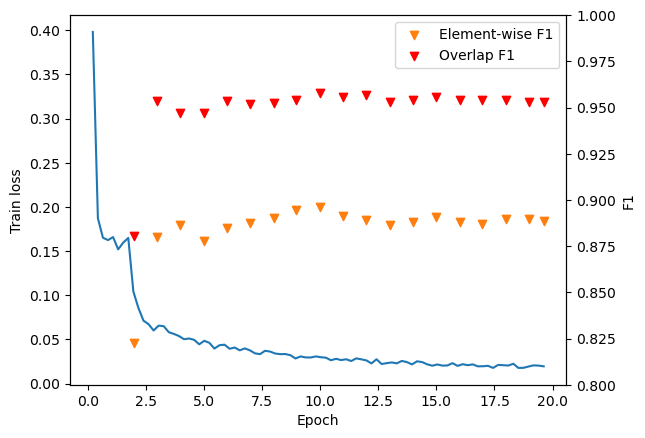

,elementwisef1,overlapf1,elementwiseprecision,overlapprecision,elementwiserecall,overlaprecall,step,epoch
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45,0.980926
1,0.822444,0.880518,0.935684,0.846743,0.744495,0.936170,91,1.983651
2,0.879950,0.953291,0.933888,0.943243,0.842465,0.972617,137,2.986376
3,0.886211,0.947094,0.903361,0.934933,0.881548,0.970588,183,3.989101
4,0.877677,0.946846,0.919104,0.935467,0.855349,0.968528,229,4.991826
5,0.884565,0.953723,0.933802,0.953211,0.850602,0.963452,275,5.994550
6,0.887391,0.951915,0.924057,0.945900,0.864071,0.967579,321,6.997275
7,0.890018,0.952203,0.927514,0.943482,0.864272,0.969605,367,8.000000
8,0.894671,0.954290,0.902913,0.947730,0.895331,0.968592,412,8.980926
9,0.896160,0.957748,0.902941,0.948090,0.897581,0.974671,458,9.983651


In [5]:
import pandas as pd
from pathlib import Path
import json


paths = Path("model_filledPause_3e-5_20_4/").glob("checkpoint-*stats.jsonl")
data = []

for f in paths:
    df = pd.read_json(f, lines=True).dropna()
    data.append(
        {
            "elementwisef1": (
                df["f1-score_elementwise"]
                * df.support_elementwise
                / df.support_elementwise.sum()
            ).sum(),
            "overlapf1": (
                df["f1-score_overlap"] * df.support_overlap / df.support_overlap.sum()
            ).sum(),
            "elementwiseprecision": (
                df["precision_elementwise"]
                * df.support_elementwise
                / df.support_elementwise.sum()
            ).sum(),
            "overlapprecision": (
                df["precision_overlap"] * df.support_overlap / df.support_overlap.sum()
            ).sum(),
            "elementwiserecall": (
                df["recall_elementwise"]
                * df.support_elementwise
                / df.support_elementwise.sum()
            ).sum(),
            "overlaprecall": (
                df["recall_overlap"] * df.support_overlap / df.support_overlap.sum()
            ).sum(),
            "step": int(f.name.split("checkpoint-")[-1].split("_stats")[0]),
        }
    )
metricsdf = pd.DataFrame(data=data).sort_values("step").reset_index(drop=True)


latest = Path("model_filledPause_3e-5_20_4/checkpoint-900/trainer_state.json")
df = pd.json_normalize(json.loads(latest.read_text())["log_history"])
c = df.iloc[-1, 0] / df.iloc[-1, -1]

metricsdf["epoch"] = metricsdf.step.apply(lambda i: i * c)
import matplotlib.pyplot as plt


plt.plot(df.epoch, df.loss, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.twinx()
plt.scatter(
    metricsdf.epoch,
    metricsdf.elementwisef1,
    marker="v",
    c="tab:orange",
    label="Element-wise F1",
)
plt.scatter(
    metricsdf.epoch, metricsdf.overlapf1, marker="v", c="red", label="Overlap F1"
)

plt.ylim((0.8, 1))
plt.ylabel("F1")
plt.legend()

plt.show()
metricsdf

In [6]:
df = pd.read_json(f, lines=True).dropna()
for c in df.columns:


SyntaxError: incomplete input (1217268208.py, line 2)